In [1]:
#load in packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
#load in data
df=pd.read_csv('crypto_data_top_200.csv')
df.head(15)

,Name,Symbol,Price,24h Change (%),7d Change (%),Market Cap,Volume (24h),Circulating Supply
0,Bitcoin,BTC,102971.223913,-2.991204,1.440347,2.054022e+12,7.141545e+10,1.994753e+07
1,Ethereum,ETH,3418.604055,-4.229401,3.791285,4.126137e+11,3.961090e+10,1.206965e+08
2,Tether USDt,USDT,0.999628,-0.013592,-0.043770,1.834296e+11,1.397560e+11,1.834978e+11
3,XRP,XRP,2.395534,-5.342619,8.296253,1.439888e+11,4.512608e+09,6.010720e+10
4,BNB,BNB,960.620244,-3.304135,2.501442,1.323131e+11,2.691724e+09,1.377372e+08
5,Solana,SOL,155.205064,-7.428042,-0.150505,8.596920e+10,6.143381e+09,5.539072e+08
6,USDC,USDC,0.999974,0.003429,0.006986,7.599844e+10,1.570353e+10,7.600038e+10
7,TRON,TRX,0.297643,0.501566,4.274401,2.817742e+10,7.539868e+08,9.466850e+10
8,Dogecoin,DOGE,0.172388,-5.343457,5.964384,2.615731e+10,2.096795e+09,1.517347e+11
9,Cardano,ADA,0.558425,-5.839241,7.187557,2.003130e+10,8.550484e+08,3.587106e+10


In [3]:
#get rid of symbol, 24h change
df=df.drop(columns=['Symbol','24h Change (%)'])
df.head(5)

,Name,Price,7d Change (%),Market Cap,Volume (24h),Circulating Supply
0,Bitcoin,102971.223913,1.440347,2.054022e+12,7.141545e+10,1.994753e+07
1,Ethereum,3418.604055,3.791285,4.126137e+11,3.961090e+10,1.206965e+08
2,Tether USDt,0.999628,-0.043770,1.834296e+11,1.397560e+11,1.834978e+11
3,XRP,2.395534,8.296253,1.439888e+11,4.512608e+09,6.010720e+10
4,BNB,960.620244,2.501442,1.323131e+11,2.691724e+09,1.377372e+08


In [ ]:
#summary statistics
df.describe()
df.info()
#table of means: price, market cap, volume (24h), circulating supply
mean_values=df[['Price','Market Cap','Volume (24h)','Circulating Supply']].mean()
print("Mean Values:\n", mean_values)
#table of medians: price, market cap, volume (24h), circulating supply
median_values=df[['Price','Market Cap','Volume (24h)','Circulating Supply']].median()
print("Median Values:\n", median_values)
# max and min values for price, market cap, volume (24h), circulating supply by cryptocurrency
max_values=df[['Price','Market Cap','Volume (24h)','Circulating Supply']].max()
min_values=df[['Price','Market Cap','Volume (24h)','Circulating Supply']].min()
print("Max Values:\n", max_values)
print("Min Values:\n", min_values) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                200 non-null    object 
 1   Price               200 non-null    float64
 2   7d Change (%)       200 non-null    float64
 3   Market Cap          200 non-null    float64
 4   Volume (24h)        200 non-null    float64
 5   Circulating Supply  200 non-null    float64
dtypes: float64(5), object(1)
memory usage: 9.5+ KB
Mean Values:
 Price                 6.168717e+02
Market Cap            1.717753e+10
Volume (24h)          1.634379e+09
Circulating Supply    1.651720e+13
dtype: float64
Median Values:
 Price                 5.780174e-01
Market Cap            5.276325e+08
Volume (24h)          4.717654e+07
Circulating Supply    1.045739e+09
dtype: float64
Max Values:
 Price                 1.029712e+05
Market Cap            2.054022e+12
Volume (24h)          1.39756

In [5]:
#log transform market cap, volume, price, circulating supply, 7d change
df['Market Cap']=np.log(df['Market Cap'])
df['Volume (24h)']=np.log(df['Volume (24h)'])
df['Price']=np.log(df['Price'])
df['Circulating Supply']=np.log(df['Circulating Supply'])
# IMPORTANT: don't take log of percent changes that can be negative or zero.
# df['7d Change (%)']=np.log(df['7d Change (%)'])  # <-- removed to avoid -inf/NaN when values <= 0

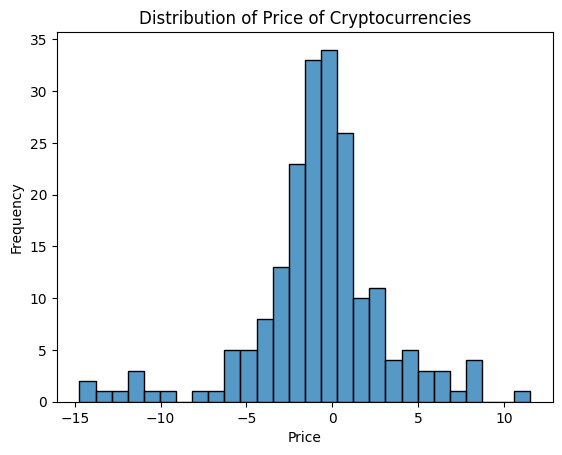

In [6]:
#distribution of price
sns.histplot(df['Price'])
plt.title('Distribution of Price of Cryptocurrencies')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


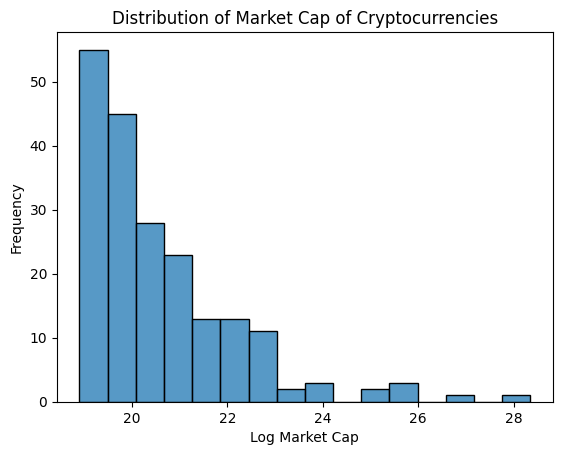

In [7]:
#distribution of market cap
sns.histplot(df['Market Cap'])
plt.title('Distribution of Market Cap of Cryptocurrencies')
plt.xlabel('Log Market Cap')
plt.ylabel('Frequency')
plt.show()

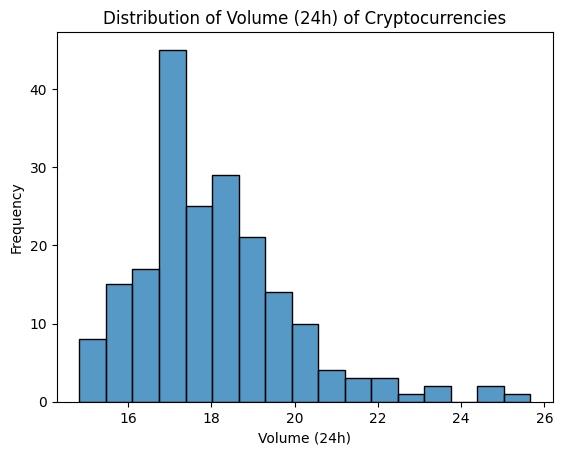

In [8]:
#distribution of volume
sns.histplot(df['Volume (24h)'])
plt.title('Distribution of Volume (24h) of Cryptocurrencies')
plt.xlabel('Volume (24h)')
plt.ylabel('Frequency')
plt.show()

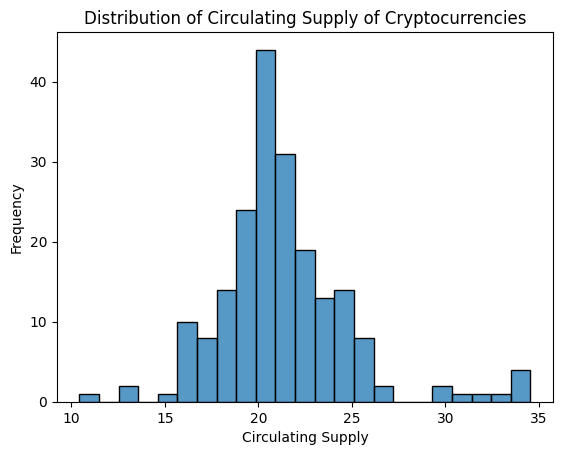

In [9]:
#distribution of circulating supply
sns.histplot(df['Circulating Supply'])
plt.title('Distribution of Circulating Supply of Cryptocurrencies')
plt.xlabel('Circulating Supply')
plt.ylabel('Frequency')
plt.show()

In [10]:
#correlation matrix, remove non-numeric columns
corr_matrix=df.corr(numeric_only=True)
print("Correlation Matrix:\n", corr_matrix)

Correlation Matrix:
                        Price  7d Change (%)  Market Cap  Volume (24h)  \
Price               1.000000       0.007698    0.373784      0.365857   
7d Change (%)       0.007698       1.000000   -0.049178      0.066854   
Market Cap          0.373784      -0.049178    1.000000      0.773839   
Volume (24h)        0.365857       0.066854    0.773839      1.000000   
Circulating Supply -0.908510      -0.030445    0.047989     -0.045365   

                    Circulating Supply  
Price                        -0.908510  
7d Change (%)                -0.030445  
Market Cap                    0.047989  
Volume (24h)                 -0.045365  
Circulating Supply            1.000000  


Text(0.5, 1.0, 'Linear Regression: Circulating Supply vs Price')

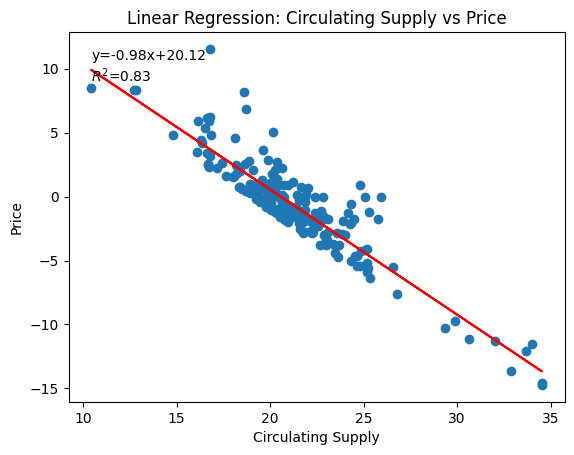

In [11]:
#simple linear regression between log(price) and (circulating supply)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Circulating Supply'], df['Price'])
#plot regression line
plt.scatter(df['Circulating Supply'], df['Price'])
plt.plot(df['Circulating Supply'], intercept + slope*df['Circulating Supply'], 'r', label='Fitted Line')
plt.xlabel('Circulating Supply')
plt.ylabel('Price')
#add equation and r-squared to plot
plt.text(min(df['Circulating Supply']), max(df['Price']), f'y={slope:.2f}x+{intercept:.2f}\n$R^2$={r_value**2:.2f}', fontsize=10, verticalalignment='top')
plt.title('Linear Regression: Circulating Supply vs Price')

Text(0.5, 0, 'Volume (24h)')

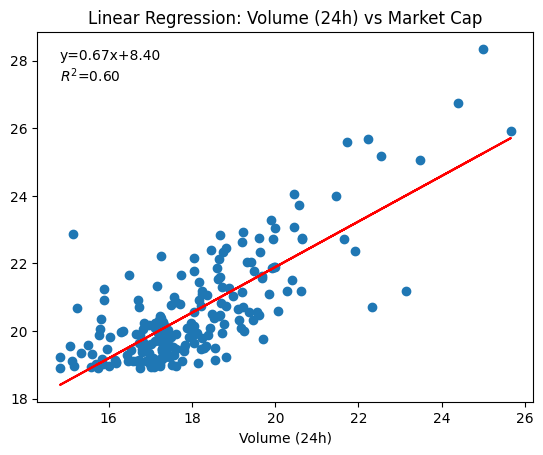

In [12]:
#simple linear regression between log(volume) and (market cap)
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Volume (24h)'], df['Market Cap'])
#plot regression line
plt.scatter(df['Volume (24h)'], df['Market Cap'], label='Data Points')
plt.plot(df['Volume (24h)'], intercept + slope*df['Volume (24h)'], 'r', label='Fitted Line')
plt.title('Linear Regression: Volume (24h) vs Market Cap')
#add equation and r-squared to plot
plt.text(min(df['Volume (24h)']), max(df['Market Cap']), f'y={slope:.2f}x+{intercept:.2f}\n$R^2$={r_value**2:.2f}', fontsize=10, verticalalignment='top')
plt.xlabel('Volume (24h)')
